# Calling a minimal DIRAC setup to obtain matrix elements and Basis definitions

In [1]:
from ase import Atoms
from ase.io import read
from ase.units import Ha
from ase_dirac import DIRAC
from ase.calculators.calculator import CalculationFailed
import h5py
import numpy as np
from typing import Optional, Union, Literal, List, Tuple
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from py_mods.src.integrals.GTO import GTO, create_normalized_GTO, S_3D_uncontracted_GTO_list, create_GTO
from py_mods.src.SCF.plot_utilities import plot_map

In [2]:
xyz_string = """2
F2
H      0 0 0
H      0.00000      0.0     -1.0
"""

inp_str = """ 
**DIRAC
.TITLE
Molecular Te. DEA from the dianion.
.WAVE F
**HAMILTONIAN
.LVCORR
**WAVE FUNCTIONS
.SCF
*SCF
.MAXITR
1
**MOLECULE
*BASIS
.DEFAULT
dyall.2zp
.NOSYM
*END OF
"""

with open("diatomic.xyz", "w") as f:
    f.write(xyz_string)

with open("nonrel_scf.inp", "w") as f:
    f.write(inp_str)

ase_molecule = DIRAC.ASE_atoms_from_inpfile_and_coords("nonrel_scf.inp", "diatomic.xyz")

In [3]:
try:
    ase_molecule.get_potential_energy() / Ha
except CalculationFailed: 
    print("\n\nCalculation failed because we requested a single SCF iteration so it is obviously not converged.")
    is_there_h5 = ase_molecule.calc.h5_exists
    print(f'However, h5 file is ready: {is_there_h5}')

 starting DIRAC for molecule nonrel_scf_diatomic.xyz with input nonrel_scf_diatomic.inp
  creating archive file  nonrel_scf_diatomic.tgz
  archived working files: ['MOLECULE.XYZ', 'DIRAC.INP', 'AOPROPER', 'AOMOMAT', 'dirac.xml']
  exit           : ABNORMAL (CHECK DIRAC OUTPUT)


Calculation failed because we requested a single SCF iteration so it is obviously not converged.
However, h5 file is ready: True


In [4]:
ase_molecule.calc.h5_contents[0:25]

['Group: input',
 'Group: input/aobasis',
 'Group: input/aobasis/1',
 'Dataset: input/aobasis/1/angular (1,)',
 'Dataset: input/aobasis/1/aobasis_id (1,)',
 'Dataset: input/aobasis/1/center (21,)',
 'Dataset: input/aobasis/1/contractions (7,)',
 'Dataset: input/aobasis/1/exponents (7,)',
 'Dataset: input/aobasis/1/n_ao (1,)',
 'Dataset: input/aobasis/1/n_cont (7,)',
 'Dataset: input/aobasis/1/n_prim (7,)',
 'Dataset: input/aobasis/1/n_shells (1,)',
 'Dataset: input/aobasis/1/orbmom (7,)',
 'Group: input/aobasis/2',
 'Dataset: input/aobasis/2/angular (1,)',
 'Dataset: input/aobasis/2/aobasis_id (1,)',
 'Dataset: input/aobasis/2/center (24,)',
 'Dataset: input/aobasis/2/contractions (8,)',
 'Dataset: input/aobasis/2/exponents (8,)',
 'Dataset: input/aobasis/2/n_ao (1,)',
 'Dataset: input/aobasis/2/n_cont (8,)',
 'Dataset: input/aobasis/2/n_prim (8,)',
 'Dataset: input/aobasis/2/n_shells (1,)',
 'Dataset: input/aobasis/2/orbmom (8,)',
 'Dataset: input/dirac_inp (33,)']

In [5]:
data_L = ase_molecule.calc.extract_h5_value("input/aobasis/1/")
data_S = ase_molecule.calc.extract_h5_value("input/aobasis/2/")
one_electron_ints_symm = ase_molecule.calc.extract_h5_value("result/operators/ao_matrices")

In [6]:
def extract_basis_data(Dirac_Calculator: DIRAC, component: Literal['Large', 'Small']='Large'):
    if not Dirac_Calculator.h5_exists:
        raise FileNotFoundError('There is no availiable h5 file')
    
    if component not in ['Large', 'Small']:
        raise ValueError("Component must be either 'Large' or 'Small'")
    
    basis_number = '1' if component == 'Large' else '2'


    R_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/center').reshape(-1,3)
    exps_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/exponents')
    l_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/orbmom')

    print(R_array)
    print(exps_array)
    print(l_array)
    


"""
Dataset: input/aobasis/1/angular (1,)
Dataset: input/aobasis/1/aobasis_id (1,)
Dataset: input/aobasis/1/center (33,)
Dataset: input/aobasis/1/contractions (11,)
Dataset: input/aobasis/1/exponents (11,)
Dataset: input/aobasis/1/n_ao (1,)
Dataset: input/aobasis/1/n_cont (11,)
Dataset: input/aobasis/1/n_prim (11,)
Dataset: input/aobasis/1/n_shells (1,)
Dataset: input/aobasis/1/orbmom (11,)
"""
    


'\nDataset: input/aobasis/1/angular (1,)\nDataset: input/aobasis/1/aobasis_id (1,)\nDataset: input/aobasis/1/center (33,)\nDataset: input/aobasis/1/contractions (11,)\nDataset: input/aobasis/1/exponents (11,)\nDataset: input/aobasis/1/n_ao (1,)\nDataset: input/aobasis/1/n_cont (11,)\nDataset: input/aobasis/1/n_prim (11,)\nDataset: input/aobasis/1/n_shells (1,)\nDataset: input/aobasis/1/orbmom (11,)\n'

In [7]:
extract_basis_data(ase_molecule.calc, 'Large')

[[0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]]
[82.9687389  12.4571508   2.83382422  0.80016414  0.25862944  0.08997668
  0.5024489 ]
[1 1 1 1 1 1 2]


In [8]:
extract_basis_data(ase_molecule.calc, 'Small')

[[0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]]
[ 0.5024489  82.9687389  12.4571508   2.83382422  0.80016414  0.25862944
  0.08997668  0.5024489 ]
[1 2 2 2 2 2 2 3]


In [ ]:
ase_molecule.calc.extract_h5_value("input/molecule/geometry") 

array([ 0. ,  0. ,  0.5,  0. ,  0. , -0.5])

In [10]:
ase_molecule.calc.h5_contents[0:25]

['Group: input',
 'Group: input/aobasis',
 'Group: input/aobasis/1',
 'Dataset: input/aobasis/1/angular (1,)',
 'Dataset: input/aobasis/1/aobasis_id (1,)',
 'Dataset: input/aobasis/1/center (21,)',
 'Dataset: input/aobasis/1/contractions (7,)',
 'Dataset: input/aobasis/1/exponents (7,)',
 'Dataset: input/aobasis/1/n_ao (1,)',
 'Dataset: input/aobasis/1/n_cont (7,)',
 'Dataset: input/aobasis/1/n_prim (7,)',
 'Dataset: input/aobasis/1/n_shells (1,)',
 'Dataset: input/aobasis/1/orbmom (7,)',
 'Group: input/aobasis/2',
 'Dataset: input/aobasis/2/angular (1,)',
 'Dataset: input/aobasis/2/aobasis_id (1,)',
 'Dataset: input/aobasis/2/center (24,)',
 'Dataset: input/aobasis/2/contractions (8,)',
 'Dataset: input/aobasis/2/exponents (8,)',
 'Dataset: input/aobasis/2/n_ao (1,)',
 'Dataset: input/aobasis/2/n_cont (8,)',
 'Dataset: input/aobasis/2/n_prim (8,)',
 'Dataset: input/aobasis/2/n_shells (1,)',
 'Dataset: input/aobasis/2/orbmom (8,)',
 'Dataset: input/dirac_inp (33,)']

Lets manually run pam and check the out the h5 file:

In [11]:
!grep .NOSYM nonrel_scf.inp -C 2

!pam --inp=nonrel_scf.inp --mol=F2.xyz > /dev/null 2>&1  

with h5py.File(f"nonrel_scf_diatomic.h5", "r") as f:
    coords = f["input/aobasis/1/center"][()].reshape(-1,3)

print("\n\n",coords)

.DEFAULT
dyall.2zp
.NOSYM
*END OF


 [[0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]
 [0.         0.         0.94486306]]


So here, it is possible to see that even though we have inputed a $H_2$ molecule, the `h5` file contains only one of these positions in the basis definition. I assume that evem though `.Nosym` was selected, in the basis definition or the dump to `h5`, symmetry is enforced for this particular case. This could be discussed and eventually handled externally via a grep of sorts. 

---

For now we will restrict ourselves to a non-symmetric case such as `H-He`, in order to avoid this (for now). Therefore: 


In [12]:
xyz_string = """2
F2
H      0 0 0
He      0.00000      0.0     -1.0
"""

with open("diatomic.xyz", "w") as f:
    f.write(xyz_string)


ase_molecule = DIRAC.ASE_atoms_from_inpfile_and_coords("nonrel_scf.inp", "diatomic.xyz")

try:
    ase_molecule.get_potential_energy() / Ha
except CalculationFailed: 
    print("\n\nCalculation failed because we requested a single SCF iteration so it is obviously not converged.")
    is_there_h5 = ase_molecule.calc.h5_exists
    print(f'However, h5 file is ready: {is_there_h5}')

 starting DIRAC for molecule nonrel_scf_diatomic.xyz with input nonrel_scf_diatomic.inp
  creating archive file  nonrel_scf_diatomic.tgz
  archived working files: ['MOLECULE.XYZ', 'DIRAC.INP', 'AOPROPER', 'AOMOMAT', 'dirac.xml']
  exit           : ABNORMAL (CHECK DIRAC OUTPUT)


Calculation failed because we requested a single SCF iteration so it is obviously not converged.
However, h5 file is ready: True


Lets check out the basis information:

In [13]:
!grep 'Atoms and basis sets'  nonrel_scf_diatomic.out -A 16

  Atoms and basis sets
  --------------------

  Number of atom types :    2
  Total number of atoms:    2

  label    atoms   charge   prim    cont     basis   
  ----------------------------------------------------------------------
  H           1       1       9       9      L  - [6s1p|6s1p]                                                    
                             25      25      S  - [1s6p1d|1s6p1d]                                                
  He          1       2       9       9      L  - [6s1p|6s1p]                                                    
                             25      25      S  - [1s6p1d|1s6p1d]                                                
  ----------------------------------------------------------------------
                             18      18      L  - large components
                             50      50      S  - small components
  ----------------------------------------------------------------------
  total:      2       3      

And we define the information extractor:

In [14]:
def extract_basis_data(Dirac_Calculator: DIRAC, component: Literal['Large', 'Small']='Large') -> Tuple[NDArray]:
    if not Dirac_Calculator.h5_exists:
        raise FileNotFoundError('There is no availiable h5 file')
    
    if component not in ['Large', 'Small']:
        raise ValueError("Component must be either 'Large' or 'Small'")
    
    basis_number = '1' if component == 'Large' else '2'


    R_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/center').reshape(-1,3)
    exps_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/exponents')
    l_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/orbmom')
    contraction_array = Dirac_Calculator.extract_h5_value(f'input/aobasis/{basis_number}/contractions')
    contraction_array = np.zeros_like(contraction_array) + 1


    # print(R_array)
    # print(exps_array)
    # print(l_array)

    return (R_array, exps_array, l_array-1, contraction_array)# -1 here due to the angular momentum indexing starting at 1 in Fortran.  *0.529177
    

In [15]:
extract_basis_data(ase_molecule.calc, 'Large')

(array([[ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        ,  1.50961624],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989],
        [ 0.        ,  0.        , -0.38010989]]),
 array([8.29687389e+01, 1.24571508e+01, 2.83382422e+00, 8.00164139e-01,
        2.58629441e-01, 8.99766770e-02, 5.02448897e-01, 2.34522333e+02,
        3.52200252e+01, 7.99840299e+00, 2.21385929e+00, 6.67371603e-01,
        2.09005872e-01, 1.27228449e+00]),
 array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]),
 a

In [16]:
def construct_GTOs_from_basis_data(basis_data, hermit_norm=False):
    R_array, exps_array, l_array, contraction_array = basis_data
    GTOs = []
    for center, exps, l, contraction in zip(R_array, exps_array, l_array, contraction_array):
        gto = create_normalized_GTO(center, exps, l, hermit_norm=hermit_norm)
        # gto = create_GTO(center, exps, l)
        gto.normalization_constants *= contraction
        GTOs.append(gto)
    return GTOs

In [17]:
basis_data: Tuple[NDArray] = extract_basis_data(ase_molecule.calc, 'Large')
L_GTOs: List[GTO] = construct_GTOs_from_basis_data(basis_data, hermit_norm=True)
L_GTOs

[GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(82.9687389), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([19.59277535]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(12.4571508), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([4.72578689]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(2.83382422), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([1.55664569]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(0.800164139), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([0.6029682]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(0.258629441), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32)

In [18]:
print(sum([len(i.l_projections) for i in L_GTOs]))

18


In [19]:
small_basis_data = extract_basis_data(ase_molecule.calc, 'Small')
S_GTOs = construct_GTOs_from_basis_data(small_basis_data, hermit_norm=True)
LS_GTOs = L_GTOs + S_GTOs

print(len(LS_GTOs))

30


In [20]:
total_basis = 0 
for gto in LS_GTOs:
    total_basis += len(gto.l_projections)
total_basis

68

As expected from the grep. 

In [21]:
l_list = ['S', 'P', 'D', 'F', 'G', 'H']
R_array, exps_array, l_array, contraction_array = extract_basis_data(ase_molecule.calc, 'Large')
# for e, l, c in zip(exps_array, l_array, contraction_array):
#     print(f"H {l_list[l]}\n {e}   {c}")

In [22]:
l_list = ['S', 'P', 'D', 'F', 'G', 'H']
R_array, exps_array, l_array, contraction_array = extract_basis_data(ase_molecule.calc, 'Small')
# for e, l, c in zip(exps_array, l_array, contraction_array):
#     print(f"H {l_list[l]}\n {e}   {c}")

In [23]:
L_GTOss= sorted(L_GTOs[:14], key=lambda gto: gto.total_L)
L_GTOss

[GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(82.9687389), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([19.59277535]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(12.4571508), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([4.72578689]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(2.83382422), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([1.55664569]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(0.800164139), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([0.6029682]), charge=1),
 GTO(R=array([0.        , 0.        , 1.50961624]), exp=np.float64(0.258629441), total_L=np.int64(0), l_projections=array([[0, 0, 0]], dtype=int32)

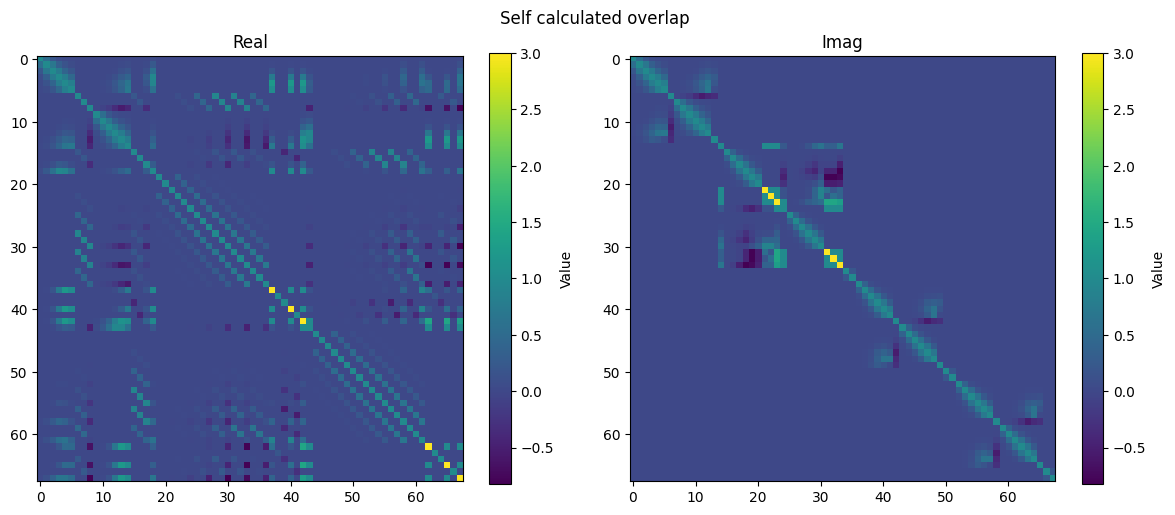

In [ ]:
def retriangularize_and_conjugate(array, n_basis):
    M = np.zeros((n_basis, n_basis), dtype=array.dtype)
    k = 0
    for j in range(n_basis):
        for i in range(j + 1):
            M[i, j] = array[k]
            M[j, i] = np.conjugate(array[k])
            k += 1
    return M


n = int(ase_molecule.calc.extract_h5_value("result/operators/ao_matrices/aobasis_dim")[0])

array = ase_molecule.calc.extract_h5_value("result/operators/ao_matrices/OVERLAP TFFT")[:]
array2 = retriangularize_and_conjugate(array, n)


LS_GTOs_sorted = LS_GTOs

LS_GTOs: List[GTO] = L_GTOs + S_GTOs
S_full_basis: NDArray[np.float64] = S_3D_uncontracted_GTO_list(LS_GTOs)

S_full_basis = S_3D_uncontracted_GTO_list(LS_GTOs_sorted)



tmp = np.array(S_full_basis, dtype=np.complex128) 
tmp.imag = array2
plot_map(tmp[:18,:18], title='Self calculated overlap')


In [63]:
w, n = np.linalg.eigh(tmp.real[0:9, 0:9])

n.shape

(9, 9)

In [67]:
1/w**2

array([8.56362235e+02, 5.43927490e+01, 7.30586448e+00, 1.46373848e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 3.79732710e-01,
       1.10305448e-01])

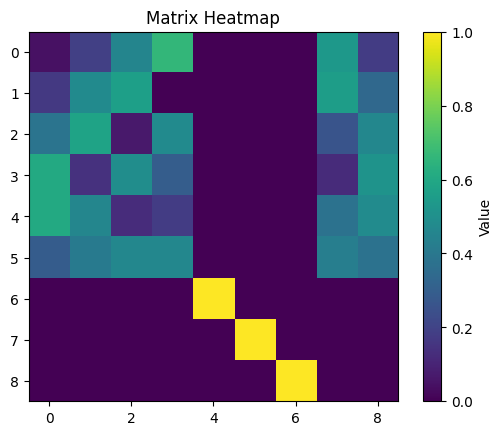

In [65]:
plot_map(np.abs(n))

In [ ]:
p

In [27]:
ase_molecule.calc.extract_h5_value("result/operators/ao_matrices/aobasis_dim")[0]

np.int64(68)